# Emotion Classification with Text Embeddings
## Pipeline: Audio → Whisper (Transcription) → DistilBERT (Text Embedding) → Classifier

This notebook transcribes audio files to text using Whisper, embeds the text with DistilBERT, and trains the same emotion classifier as the audio-based approach. The text embeddings are aggregated to match the 3072-dimensional format of the wav2emotion pipeline.

In [13]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

from config import EMOTION_DICT, USE_CUDA
from utils import load_ravdess_data, check_emotion_distribution
from models import (
    EmotionClassifier, prepare_data, create_dataloaders, train_model, 
    evaluate, analyze_training_quality, EMOTION_LABELS, IDX_TO_EMOTION
)

print(f"emotions: {list(EMOTION_DICT.values())}")

emotions: ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgusted', 'surprised']


In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### Load Audio Dataset

In [15]:
import librosa
from pathlib import Path

data_folder = 'ravdess_data'
audio_files = []
emotion_labels = []

print(f"Loading audio files from {data_folder}...")

if os.path.exists(data_folder):
    for root, dirs, files in os.walk(data_folder):
        for file in sorted(files):
            if file.endswith('.wav'):
                parts = file.split('-')
                if len(parts) >= 3 and parts[2] in EMOTION_DICT:
                    audio_files.append(os.path.join(root, file))
                    emotion_labels.append(EMOTION_DICT[parts[2]])
    print(f"Found {len(audio_files)} audio files")
else:
    print(f"Folder '{data_folder}' not found")

audio_files = np.array(audio_files)
emotion_labels = np.array(emotion_labels)

check_emotion_distribution(emotion_labels)

Loading audio files from ravdess_data...
Found 1012 audio files
Found 6 emotion classes in 1012 samples


True

### Transcribe Audio to Text Using Whisper

In [16]:
import logging
from transformers import logging as hf_logging
import whisper

hf_logging.set_verbosity_error()
logging.getLogger('transformers').setLevel(logging.ERROR)

print("Loading Whisper model...")
whisper_model = whisper.load_model("base", device=device)

transcriptions = []
print("Transcribing audio files...")

for i, audio_path in enumerate(audio_files):
    try:
        waveform, sr = librosa.load(audio_path, sr=16000)
        
        result = whisper_model.transcribe(waveform, language="en", verbose=False)
        text = result["text"].strip()
        transcriptions.append(text)
        if (i + 1) % 50 == 0:
            print(f"Transcribed {i + 1}/{len(audio_files)}")
    except Exception as e:
        print(f"Error transcribing {audio_path}: {e}")
        transcriptions.append("")

transcriptions = np.array(transcriptions)
print(f"Transcription complete: {len(transcriptions)} texts")

Loading Whisper model...
Transcribing audio files...


100%|██████████| 560/560 [00:00<00:00, 1041.03frames/s]


Transcribed 50/1012


100%|██████████| 517/517 [00:00<00:00, 926.67frames/s]


Transcribed 100/1012


...

Transcribed 950/1012


100%|██████████| 430/430 [00:00<00:00, 829.34frames/s]


Transcribed 1000/1012


100%|██████████| 443/443 [00:00<00:00, 840.43frames/s]

Transcription complete: 1012 texts


### Embed Text Using DistilBERT

In [17]:
from transformers import AutoTokenizer, AutoModel

print("Loading DistilBERT model and tokenizer...")
bert_model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
bert_model = AutoModel.from_pretrained(bert_model_name).to(device)
bert_model.eval()

print(f"DistilBERT output dimension: 768")

def embed_text_batch(texts, batch_size=16):
    """Embed texts using DistilBERT and aggregate to 3072 dimensions"""
    embeddings = []
    
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        batch_texts = [t if len(t) > 0 else "[EMPTY]" for t in batch_texts]
        
        inputs = tokenizer(batch_texts, return_tensors="pt", padding=True, 
                          truncation=True, max_length=128)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = bert_model(**inputs)
            hidden_states = outputs.last_hidden_state
        
        for j in range(len(batch_texts)):
            tokens_emb = hidden_states[j]  # (seq_len, 768)
            
            mean_emb = torch.mean(tokens_emb, dim=0)
            std_emb = torch.std(tokens_emb, dim=0)
            max_emb = torch.max(tokens_emb, dim=0)[0]
            min_emb = torch.min(tokens_emb, dim=0)[0]
            
            agg_emb = torch.cat([mean_emb, std_emb, max_emb, min_emb])
            embeddings.append(agg_emb.cpu().numpy())
    
    return np.array(embeddings)

print("Embedding texts...")
X = embed_text_batch(transcriptions, batch_size=16)
y = emotion_labels

print(f"Text embeddings shape: {X.shape}")
print(f"Embedding dimension: {X.shape[1]} (matches wav2emotion: 768*4=3072)")

Loading DistilBERT model and tokenizer...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 771.05it/s]


DistilBERT output dimension: 768
Embedding texts...
Text embeddings shape: (1012, 3072)
Embedding dimension: 3072 (matches wav2emotion: 768*4=3072)


### Prepare Training Data

In [18]:
X_train, X_test, y_train, y_test, scaler = prepare_data(X, y)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

train_loader, test_loader = create_dataloaders(X_train, X_test, y_train, y_test)

model = EmotionClassifier(input_size=X_train.shape[1], num_emotions=len(EMOTION_LABELS)).to(device)

print(f"Using device: {device}")
print(f"Emotion classifier initialized")
print(f"Input size (text embeddings): {X_train.shape[1]}")
print(f"Model architecture: 4-layer network with batch normalization")


Data normalization complete. Scaler fit on training data only.
Training set size: 809
Test set size: 203
Using device: cuda
Emotion classifier initialized
Input size (text embeddings): 3072
Model architecture: 4-layer network with batch normalization


### Train Classifier

In [19]:
train_losses, train_accs, test_losses, test_accs = train_model(
    model, train_loader, test_loader, device, 
    num_epochs=30, learning_rate=0.001
)

analyze_training_quality(y_train, train_losses, test_losses)

Training Emotion Classifier on cuda...

Epoch [5/30]
  Train Loss: 1.8163, Accuracy: 18.54%
  Test Loss: 1.7308, Accuracy: 23.65%

Epoch [10/30]
  Train Loss: 1.7572, Accuracy: 23.61%
  Test Loss: 1.7429, Accuracy: 20.20%

Epoch [15/30]
  Train Loss: 1.7433, Accuracy: 23.24%
  Test Loss: 1.7096, Accuracy: 23.15%

Epoch [20/30]
  Train Loss: 1.7156, Accuracy: 24.10%
  Test Loss: 1.7027, Accuracy: 24.14%

Epoch [25/30]
  Train Loss: 1.6994, Accuracy: 24.72%
  Test Loss: 1.7137, Accuracy: 25.62%

Epoch [30/30]
  Train Loss: 1.7141, Accuracy: 25.34%
  Test Loss: 1.7025, Accuracy: 23.15%

Training complete!

Train loss improvement: 14.6%
Test loss stable (change: -6.9%)


True

### Evaluate Model Performance

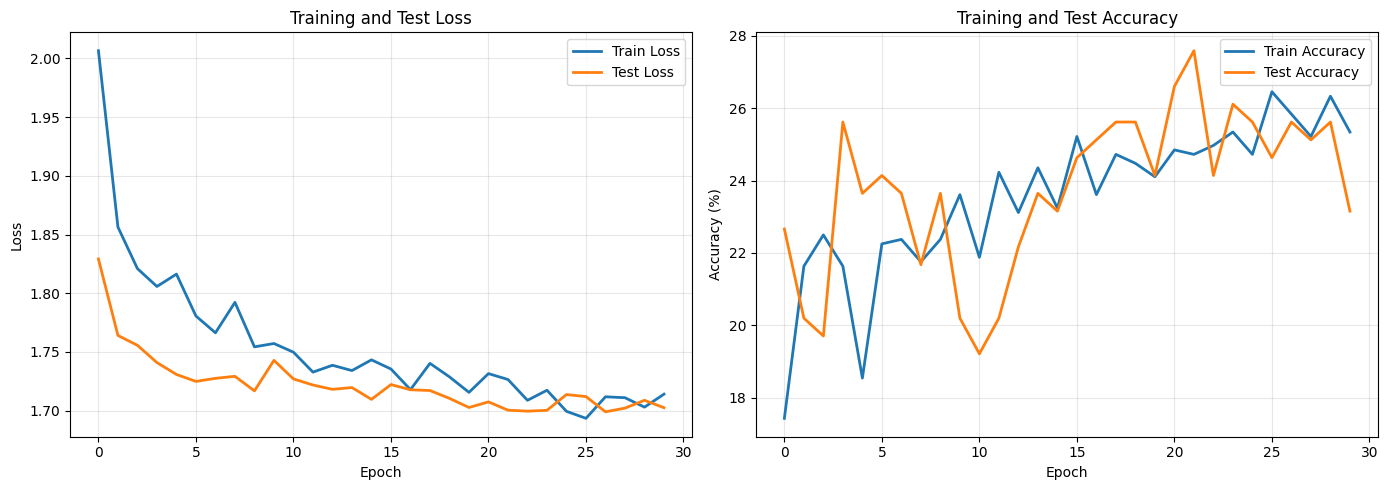

Final Test Accuracy: 23.15%


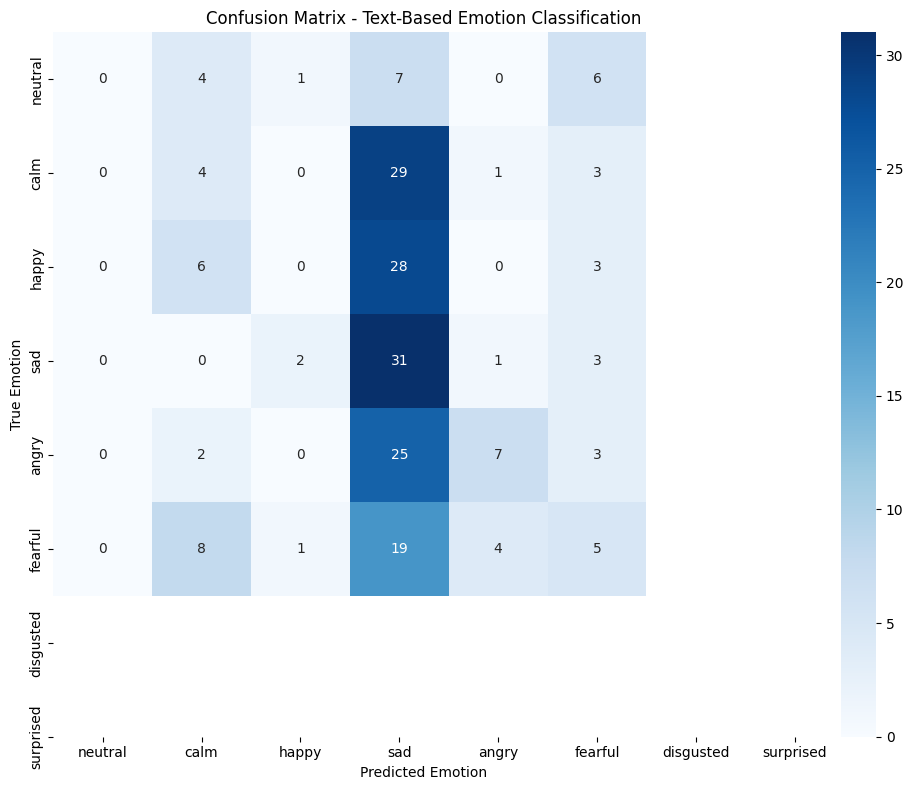


Classification Report:
Note: Only 6 emotion(s) present in test data: ['angry', 'calm', 'fearful', 'happy', 'neutral', 'sad']
              precision    recall  f1-score   support

       angry       0.54      0.19      0.28        37
        calm       0.17      0.11      0.13        37
     fearful       0.22      0.14      0.17        37
       happy       0.00      0.00      0.00        37
     neutral       0.00      0.00      0.00        18
         sad       0.22      0.84      0.35        37

    accuracy                           0.23       203
   macro avg       0.19      0.21      0.16       203
weighted avg       0.21      0.23      0.17       203



In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(test_losses, label='Test Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Test Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs, label='Train Accuracy', linewidth=2)
axes[1].plot(test_accs, label='Test Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Test Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

_, final_acc, all_preds, all_labels = evaluate(model, test_loader, nn.CrossEntropyLoss(), device)
print(f"Final Test Accuracy: {final_acc:.2f}%")

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS)
plt.title('Confusion Matrix - Text-Based Emotion Classification')
plt.ylabel('True Emotion')
plt.xlabel('Predicted Emotion')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
true_labels = [IDX_TO_EMOTION[idx] for idx in all_labels]
pred_labels = [IDX_TO_EMOTION[idx] for idx in all_preds]

unique_labels = sorted(set(true_labels + pred_labels))
if len(unique_labels) == len(EMOTION_LABELS):
    print(classification_report(true_labels, pred_labels, target_names=EMOTION_LABELS))
else:
    print(f"Note: Only {len(unique_labels)} emotion(s) present in test data: {unique_labels}")
    print(classification_report(true_labels, pred_labels, labels=unique_labels))